1.Data Preprocessing

In [ ]:
import pandas as pd
import re
import numpy as np

def preprocess_bikes_data(file_path):
    """
    Preprocess the used bikes CSV file
    """
    # Read the CSV file
    df = pd.read_csv(file_path, encoding='utf-8')
    
    print(f"Original dataset shape: {df.shape}")
    print(f"Original columns: {df.columns.tolist()}")
    
    # ============================================
    # 1. Basic cleaning
    # ============================================
    
    # Remove leading/trailing whitespaces from string columns
    str_columns = df.select_dtypes(include=['object']).columns
    for col in str_columns:
        df[col] = df[col].str.strip()
    
    # Check for duplicates
    print(f"\nDuplicate rows: {df.duplicated().sum()}")
    df = df.drop_duplicates()
    
    # ============================================
    # 2. Clean Price column
    # ============================================
    
    def clean_price(price):
        if pd.isna(price):
            return np.nan
        # Extract numeric value from "Rs X,XXX,XXX" format
        price_str = str(price)
        # Remove 'Rs' and commas, then convert to integer
        numeric_price = re.sub(r'[^\d]', '', price_str)
        if numeric_price:
            return int(numeric_price)
        return np.nan
    
    df['Price_Numeric'] = df['Price'].apply(clean_price)
    
    # ============================================
    # 3. Clean Mileage column
    # ============================================
    
    def clean_mileage(mileage):
        if pd.isna(mileage):
            return np.nan
        mileage_str = str(mileage)
        # Remove commas and extract numeric value
        numeric_mileage = re.sub(r'[^\d]', '', mileage_str)
        if numeric_mileage:
            return int(numeric_mileage)
        return np.nan
    
    df['Mileage_Numeric'] = df['Mileage'].apply(clean_mileage)
    
    # ============================================
    # 4. Clean Capacity column
    # ============================================
    
    def clean_capacity(capacity):
        if pd.isna(capacity):
            return np.nan
        capacity_str = str(capacity)
        # Extract numeric value (cc)
        numeric_capacity = re.sub(r'[^\d]', '', capacity_str)
        if numeric_capacity:
            return int(numeric_capacity)
        return np.nan
    
    df['Capacity_Numeric'] = df['Capacity'].apply(clean_capacity)
    
    # ============================================
    # 5. Extract Location from Post_Details
    # ============================================
    
    def extract_location(post_details):
        if pd.isna(post_details):
            return np.nan
        # Pattern: "Posted on [date], [location]"
        match = re.search(r'Posted on .+?, (.+?)(?:,|$)', str(post_details))
        if match:
            return match.group(1).strip()
        return np.nan
    
    df['Location'] = df['Post_Details'].apply(extract_location)
    
    # ============================================
    # 6. Extract Date from Post_Details
    # ============================================
    
    def extract_date(post_details):
        if pd.isna(post_details):
            return np.nan
        # Pattern: "Posted on [date]"
        match = re.search(r'Posted on (\d{1,2} [A-Za-z]+)', str(post_details))
        if match:
            return match.group(1)
        return np.nan
    
    df['Post_Date'] = df['Post_Details'].apply(extract_date)
    
    # ============================================
    # 7. Standardize Brand names
    # ============================================
    
    # Common brand variations mapping
    brand_mapping = {
        'bajaj': 'Bajaj',
        'honda': 'Honda',
        'yamaha': 'Yamaha',
        'suzuki': 'Suzuki',
        'hero': 'Hero',
        'tvs': 'TVS',
        'kawasaki': 'Kawasaki',
        'demak': 'Demak',
        'aprilia': 'Aprilia',
        'ktm': 'KTM',
        'ranomoto': 'Ranomoto',
        'mahindra': 'Mahindra',
        'other brand': 'Other'
    }
    
    def standardize_brand(brand):
        if pd.isna(brand):
            return np.nan
        brand_lower = str(brand).lower().strip()
        for key, value in brand_mapping.items():
            if key in brand_lower:
                return value
        return 'Other'
    
    df['Brand_Standardized'] = df['Brand'].apply(standardize_brand)
    
    # ============================================
    # 8. Categorize by Bike Type
    # ============================================
    
    # Simplify bike type categories
    type_mapping = {
        'motorbikes': 'Motorcycle',
        'scooters': 'Scooter',
        'e-bikes': 'Electric',
        'quadricycles': 'Quadricycle'
    }
    
    def standardize_type(bike_type):
        if pd.isna(bike_type):
            return np.nan
        type_lower = str(bike_type).lower().strip()
        return type_mapping.get(type_lower, 'Other')
    
    df['Type_Standardized'] = df['Bike Type'].apply(standardize_type)
    
    # ============================================
    # 9. Create age/price ratio (value indicator)
    # ============================================
    
    current_year = 2024  # You can update this
    df['Bike_Age'] = current_year - df['Year']
    df['Price_per_Year'] = df['Price_Numeric'] / (df['Bike_Age'] + 1)  # Add 1 to avoid division by zero
    
    # ============================================
    # 10. Flag potential outliers
    # ============================================
    
    # Flag unrealistic prices
    df['Price_Outlier'] = 0
    df.loc[df['Price_Numeric'] < 10000, 'Price_Outlier'] = 1  # Too cheap
    df.loc[df['Price_Numeric'] > 5000000, 'Price_Outlier'] = 1  # Too expensive
    
    # Flag unrealistic mileage
    df['Mileage_Outlier'] = 0
    df.loc[df['Mileage_Numeric'] > 300000, 'Mileage_Outlier'] = 1  # Too high mileage
    
    # ============================================
    # 11. Create final cleaned dataframe
    # ============================================
    
    cleaned_df = pd.DataFrame({
        'Title': df['Title'],
        'Brand': df['Brand_Standardized'],
        'Model': df['Model'],
        'Year': df['Year'],
        'Type': df['Type_Standardized'],
        'Price': df['Price_Numeric'],
        'Mileage': df['Mileage_Numeric'],
        'Capacity': df['Capacity_Numeric'],
        'Location': df['Location'],
        'Post_Date': df['Post_Date'],
        'Seller': df['Seller'],
        'Bike_Age': df['Bike_Age'],
        'Price_per_Year': df['Price_per_Year'],
        'Price_Outlier': df['Price_Outlier'],
        'Mileage_Outlier': df['Mileage_Outlier'],
        'URL': df['url']
    })
    
    # Remove rows with missing critical data
    cleaned_df = cleaned_df.dropna(subset=['Price', 'Year', 'Mileage'])
    
    print(f"\nCleaned dataset shape: {cleaned_df.shape}")
    print(f"Cleaned columns: {cleaned_df.columns.tolist()}")
    
    # ============================================
    # 12. Basic statistics
    # ============================================
    
    print("\n" + "="*50)
    print("BASIC STATISTICS")
    print("="*50)
    print(f"Total listings: {len(cleaned_df)}")
    print(f"\nPrice range: Rs {cleaned_df['Price'].min():,} - Rs {cleaned_df['Price'].max():,}")
    print(f"Average price: Rs {cleaned_df['Price'].mean():,.0f}")
    print(f"Median price: Rs {cleaned_df['Price'].median():,.0f}")
    
    print(f"\nYear range: {cleaned_df['Year'].min()} - {cleaned_df['Year'].max()}")
    print(f"Average year: {cleaned_df['Year'].mean():.0f}")
    
    print(f"\nMileage range: {cleaned_df['Mileage'].min():,} - {cleaned_df['Mileage'].max():,} km")
    print(f"Average mileage: {cleaned_df['Mileage'].mean():,.0f} km")
    
    print("\n" + "="*50)
    print("TOP BRANDS")
    print("="*50)
    print(cleaned_df['Brand'].value_counts().head(10))
    
    print("\n" + "="*50)
    print("BIKE TYPES")
    print("="*50)
    print(cleaned_df['Type'].value_counts())
    
    # ============================================
    # 13. Save cleaned data
    # ============================================
    
    output_file = 'used_bikes_cleaned.csv'
    cleaned_df.to_csv(output_file, index=False, encoding='utf-8')
    print(f"\n Cleaned data saved to '{output_file}'")
    
    return cleaned_df

 
if __name__ == "__main__":
    file_path = "used-bikes.csv"  
    cleaned_data = preprocess_bikes_data(file_path)
    
    # Display sample of cleaned data
    print("\n" + "="*50)
    print("SAMPLE OF CLEANED DATA")
    print("="*50)
    print(cleaned_data.head(10).to_string())

Original dataset shape: (5016, 13)
Original columns: ['Summary', 'url', 'Title', 'Post_Details', 'Bike Type', 'Brand', 'Trim/Edition', 'Model', 'Year', 'Mileage', 'Seller', 'Capacity', 'Price']


C:\Users\User\AppData\Local\Temp\ipykernel_23020\3416953944.py:20: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  str_columns = df.select_dtypes(include=['object']).columns



Duplicate rows: 0

Cleaned dataset shape: (5016, 16)
Cleaned columns: ['Title', 'Brand', 'Model', 'Year', 'Type', 'Price', 'Mileage', 'Capacity', 'Location', 'Post_Date', 'Seller', 'Bike_Age', 'Price_per_Year', 'Price_Outlier', 'Mileage_Outlier', 'URL']

BASIC STATISTICS
Total listings: 5016

Price range: Rs 17,000 - Rs 2,500,000
Average price: Rs 316,036
Median price: Rs 255,000

Year range: 1923 - 2022
Average year: 2013

Mileage range: 75 - 950,000 km
Average mileage: 45,244 km

TOP BRANDS
Brand
Bajaj       1585
Honda       1222
Yamaha       694
TVS          602
Hero         476
Suzuki       153
Demak        118
Other         60
Ranomoto      28
Mahindra      27
Name: count, dtype: int64

BIKE TYPES
Type
Motorcycle     3605
Scooter        1404
Quadricycle       4
Electric          3
Name: count, dtype: int64

✅ Cleaned data saved to 'used_bikes_cleaned.csv'

SAMPLE OF CLEANED DATA
                          Title  Brand         Model  Year         Type    Price  Mileage  Capacity   

2. Enhanced Feature Engineering

In [ ]:
 
# Feature engineering
def enhanced_feature_engineering(df):
    df_enhanced = df.copy()
    
    # 1. Log transform skewed features
    df_enhanced['Log_Price'] = np.log1p(df_enhanced['Price'])
    df_enhanced['Log_Mileage'] = np.log1p(df_enhanced['Mileage'])
    df_enhanced['Log_Capacity'] = np.log1p(df_enhanced['Capacity'])
    
    # 2. Create interaction features
    df_enhanced['Mileage_per_Year'] = df_enhanced['Mileage'] / (df_enhanced['Bike_Age'] + 1)
    df_enhanced['Capacity_per_Year'] = df_enhanced['Capacity'] / (df_enhanced['Bike_Age'] + 1)
    
    # 3. Price segments based on percentiles
    price_percentiles = df_enhanced['Price'].quantile([0.33, 0.67])
    df_enhanced['Price_Segment'] = pd.cut(df_enhanced['Price'], 
                                          bins=[-np.inf, price_percentiles.iloc[0], 
                                                price_percentiles.iloc[1], np.inf],
                                          labels=['Budget', 'Mid-Range', 'Premium'])
    
    # 4. Age groups
    df_enhanced['Age_Group'] = pd.cut(df_enhanced['Bike_Age'],
                                       bins=[-np.inf, 3, 7, 15, np.inf],
                                       labels=['New', 'Recent', 'Old', 'Vintage'])
    
    # 5. Mileage categories
    df_enhanced['Mileage_Category'] = pd.cut(df_enhanced['Mileage'],
                                             bins=[-np.inf, 10000, 30000, 60000, np.inf],
                                             labels=['Very Low', 'Low', 'Medium', 'High'])
    
    # 6. Brand popularity (count encoding)
    brand_counts = df_enhanced['Brand'].value_counts()
    df_enhanced['Brand_Popularity'] = df_enhanced['Brand'].map(brand_counts) / len(df_enhanced)
    
    # 7. Model complexity (Model name length as proxy)
    df_enhanced['Model_Name_Length'] = df_enhanced['Model'].str.len()
    
    return df_enhanced

# Apply enhanced feature engineering
cleaned_data_enhanced = enhanced_feature_engineering(cleaned_data)

print("Enhanced features shape:", cleaned_data_enhanced.shape)
print("New columns:", [col for col in cleaned_data_enhanced.columns if col not in cleaned_data.columns])

Enhanced features shape: (5016, 26)
New columns: ['Log_Price', 'Log_Mileage', 'Log_Capacity', 'Mileage_per_Year', 'Capacity_per_Year', 'Price_Segment', 'Age_Group', 'Mileage_Category', 'Brand_Popularity', 'Model_Name_Length']


3. Price Distribution Histogram

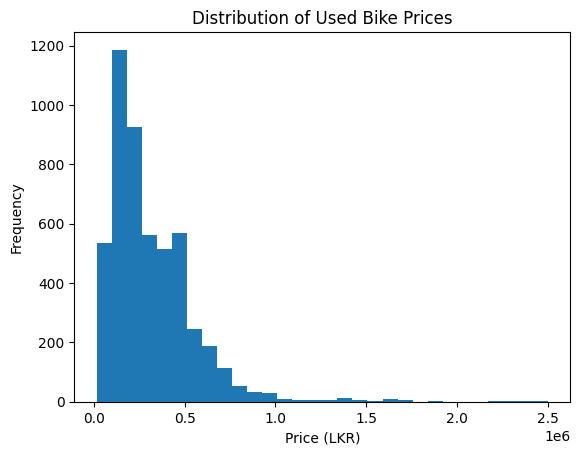

In [35]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(cleaned_data_enhanced['Price'], bins=30)
plt.xlabel("Price (LKR)")
plt.ylabel("Frequency")
plt.title("Distribution of Used Bike Prices")
plt.show()

4. Correlation Heatmap

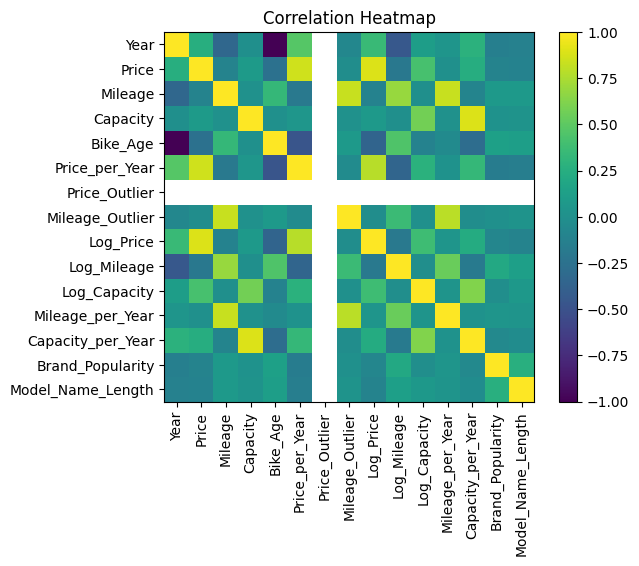

In [37]:
plt.figure()
corr_matrix = cleaned_data_enhanced.corr(numeric_only=True)
plt.imshow(corr_matrix)
plt.colorbar()
plt.title("Correlation Heatmap")
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.show()

5. Preparing Features and Splitting Data

In [ ]:

# Define expanded features
features = [
    'Brand', 'Model', 'Year', 'Type', 'Mileage', 'Capacity', 
    'Location', 'Bike_Age', 'Price_per_Year',
    'Log_Mileage', 'Log_Capacity',
    'Mileage_per_Year', 'Capacity_per_Year',
    'Price_Segment', 'Age_Group', 'Mileage_Category',
    'Brand_Popularity', 'Model_Name_Length'
]

# Define categorical features
categorical_features = ['Brand', 'Model', 'Type', 'Location', 
                       'Price_Segment', 'Age_Group', 'Mileage_Category']

# Encode categorical features as strings
for col in categorical_features:
    cleaned_data_enhanced[col] = cleaned_data_enhanced[col].astype(str)

# Remove outliers if they're too extreme
cleaned_data_filtered = cleaned_data_enhanced[
    (cleaned_data_enhanced['Price_Outlier'] == 0) & 
    (cleaned_data_enhanced['Mileage_Outlier'] == 0)
].copy()

X = cleaned_data_filtered[features]
y = cleaned_data_filtered['Price']

# Split data
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Training set size: {len(X_train)}")
print(f"Validation set size: {len(X_val)}")
print(f"Test set size: {len(X_test)}")
print(f"\nFeatures used: {len(features)}")
print(f"Categorical features: {categorical_features}")

Training set size: 3474
Validation set size: 744
Test set size: 745

Features used: 18
Categorical features: ['Brand', 'Model', 'Type', 'Location', 'Price_Segment', 'Age_Group', 'Mileage_Category']


6. CatBoost Hyperparameter Tuning

In [ ]:

from catboost import CatBoostRegressor
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

# Define hyperparameter grid for tuning
param_grid = {
    'iterations': [500, 1000, 1500],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'depth': [4, 6, 8, 10],
    'l2_leaf_reg': [1, 3, 5, 7, 10],
    'border_count': [32, 64, 128],
    'bagging_temperature': [0.5, 1, 2],
    'random_strength': [0.5, 1, 2],
    'one_hot_max_size': [2, 5, 10]
}

# Base model
base_model = CatBoostRegressor(
    loss_function='RMSE',
    eval_metric='RMSE',
    random_seed=42,
    verbose=False,
    early_stopping_rounds=50
)

# Randomized search
random_search = RandomizedSearchCV(
    base_model,
    param_distributions=param_grid,
    n_iter=20,  # Number of parameter combinations to try (reduced for faster execution)
    cv=3,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# Fit random search
print("Starting hyperparameter tuning... (this may take several minutes)")
random_search.fit(
    X_train, y_train,
    cat_features=categorical_features,
    eval_set=(X_val, y_val)
)

print("\nBest parameters:", random_search.best_params_)
print("Best RMSE:", -random_search.best_score_)

Starting hyperparameter tuning... (this may take several minutes)
Fitting 3 folds for each of 20 candidates, totalling 60 fits

Best parameters: {'random_strength': 2, 'one_hot_max_size': 2, 'learning_rate': 0.03, 'l2_leaf_reg': 1, 'iterations': 1000, 'depth': 6, 'border_count': 128, 'bagging_temperature': 0.5}
Best RMSE: 55449.79045936166


7.Training the Final CatBoost Model

In [41]:
best_params = random_search.best_params_

final_model = CatBoostRegressor(
    **best_params,
    loss_function='RMSE',
    eval_metric='RMSE',
    random_seed=42,
    verbose=100
)

final_model.fit(
    X_train, y_train,
    cat_features=categorical_features,
    eval_set=(X_val, y_val),
    early_stopping_rounds=50
)

0:	learn: 222404.5087364	test: 236001.7657417	best: 236001.7657417 (0)	total: 105ms	remaining: 1m 44s
100:	learn: 65226.4466450	test: 65849.6270112	best: 65849.6270112 (100)	total: 7.21s	remaining: 1m 4s
200:	learn: 48884.7699771	test: 51891.4239863	best: 51891.4239863 (200)	total: 14.5s	remaining: 57.5s
300:	learn: 39089.9064346	test: 44562.9025146	best: 44562.9025146 (300)	total: 21.9s	remaining: 50.9s
400:	learn: 29604.6230684	test: 36563.7486155	best: 36563.7486155 (400)	total: 30.9s	remaining: 46.1s
500:	learn: 24271.8761258	test: 32111.8106940	best: 32111.8106940 (500)	total: 38.6s	remaining: 38.5s
600:	learn: 20079.7295759	test: 29621.6195263	best: 29621.6195263 (600)	total: 46.7s	remaining: 31s
700:	learn: 17536.2112029	test: 28080.4983084	best: 28080.4983084 (700)	total: 53.8s	remaining: 22.9s
800:	learn: 15306.9618495	test: 26995.2437251	best: 26995.2437251 (800)	total: 1m 1s	remaining: 15.2s
900:	learn: 13437.7215008	test: 26229.7680039	best: 26229.7680039 (900)	total: 1m 8s

CatBoostRegressor(bagging_temperature=0.5, border_count=128, depth=6, eval_metric='RMSE', iterations=1000, l2_leaf_reg=1, learning_rate=0.03, loss_function='RMSE', one_hot_max_size=2, random_seed=42, random_strength=2, verbose=100)

8. Model Evaluation on Test Set

In [42]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

y_pred = final_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Test RMSE:", rmse)
print("Test MAE:", mae)
print("Test R2:", r2)

Test RMSE: 55813.583392587854
Test MAE: 14838.633864332445
Test R2: 0.9560419528959591


9. Visualizing Predictions vs Actuals

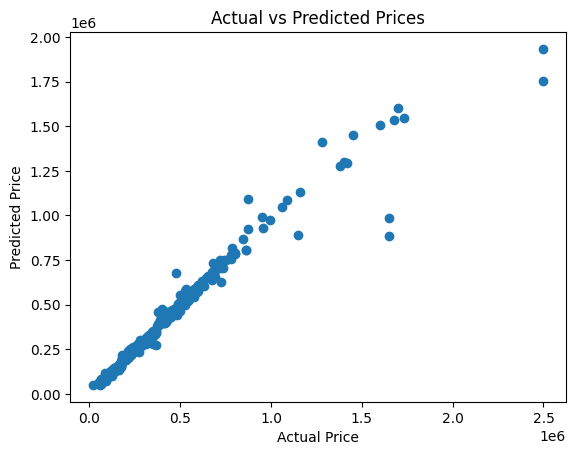

In [43]:
import matplotlib.pyplot as plt

# Actual vs Predicted
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")
plt.show()

10. Residual Analysis

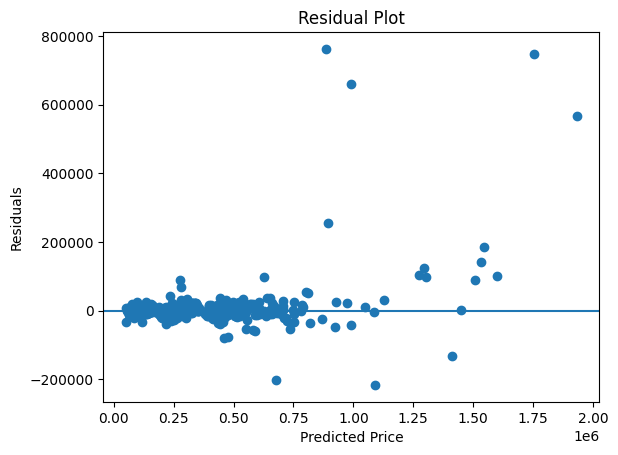

In [44]:
# Residual Plot
residuals = y_test - y_pred
plt.figure()
plt.scatter(y_pred, residuals)
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.axhline(y=0)
plt.show()

11. Feature Importance Plot

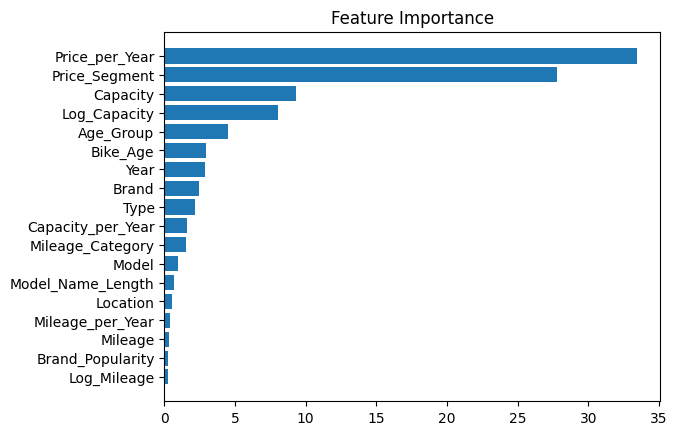

In [45]:

importance = final_model.get_feature_importance()
feature_names = X_train.columns

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

plt.figure()
plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance")
plt.show()

12. Feature Importance with SHAP

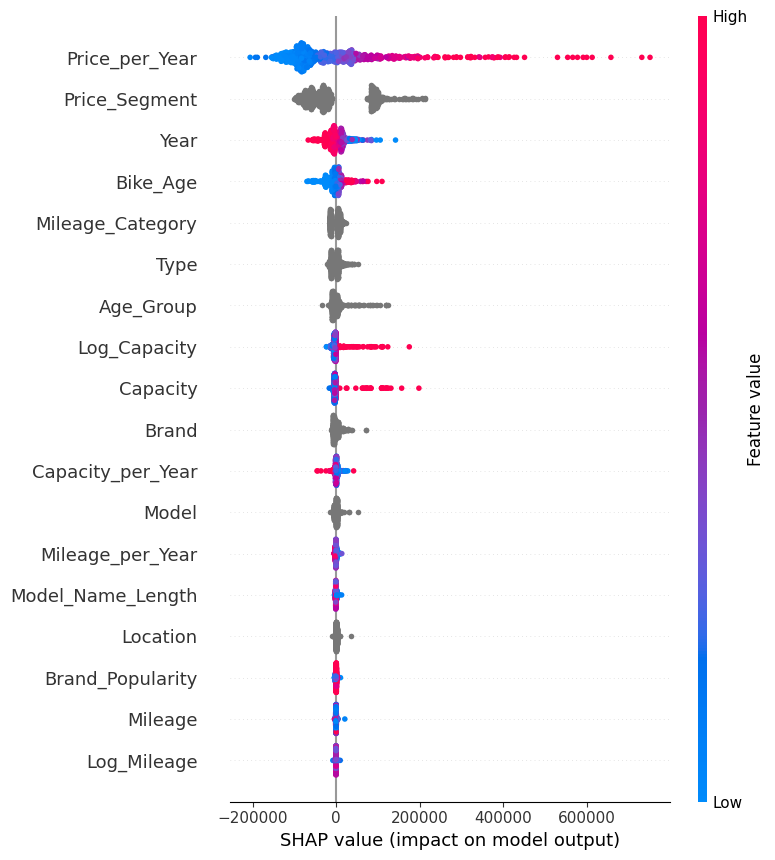

Done!


In [46]:
import shap
import joblib

# SHAP for your report
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test)

# Save for web app
final_model.save_model("bike_price_model.cbm")
joblib.dump(list(X_train.columns), "features.pkl")
joblib.dump(categorical_features, "categorical_features.pkl")
joblib.dump(X_train.sample(n=100, random_state=42), "background_sample.pkl")

print("Done!")

13. SHAP Force Plot for Individual Prediction

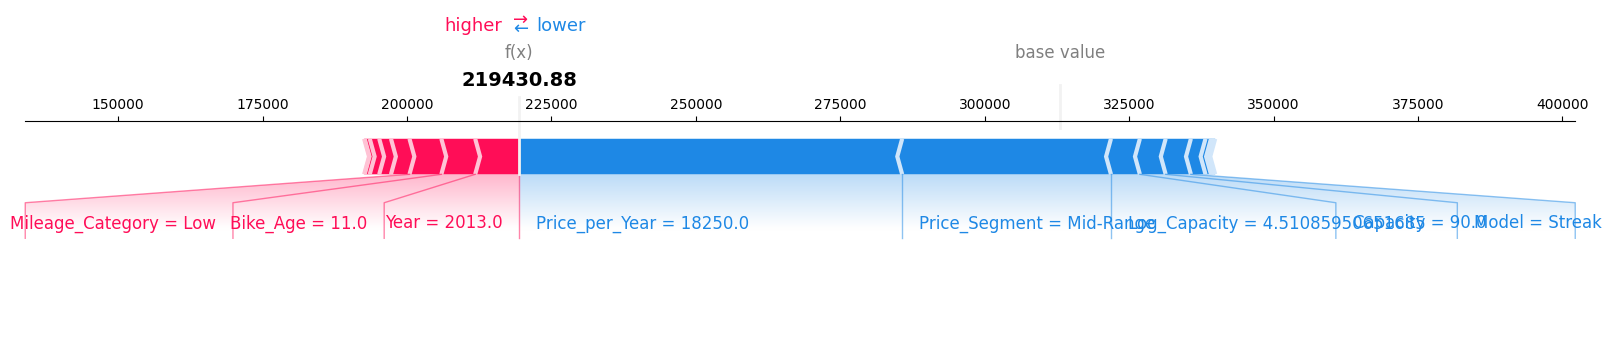

In [39]:
shap.force_plot(explainer.expected_value, 
                shap_values[0], 
                X_test.iloc[0], 
                matplotlib=True)

14. Saving the Trained Model

In [33]:
from catboost import CatBoostRegressor

final_model.save_model("bike_price_model.cbm")

15. Saving Feature Metadata

In [34]:
import joblib

joblib.dump(features, "features.pkl")
joblib.dump(categorical_features, "categorical_features.pkl")

['categorical_features.pkl']